In [1]:
import pandas as pd
import numpy as np
import re
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, GPTNeoXForCausalLM
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [2]:
syn_pairs = pd.read_csv("./dataset/synonymy_pairs.csv")
ant_pairs = pd.read_csv("./dataset/antonymy_pairs.csv")
rand_pairs = pd.read_csv("./dataset/random_pairs.csv")

print("Synonymy pairs:", syn_pairs.shape)
print("Antonymy pairs:", ant_pairs.shape)
print("Random pairs:", rand_pairs.shape)

# Quick peek at each
print("\nSynonymy head:\n", syn_pairs.head())
print("\nAntonymy head:\n", ant_pairs.head())
print("\nRandom head:\n", rand_pairs.head())

Synonymy pairs: (1000, 2)
Antonymy pairs: (1000, 2)
Random pairs: (1000, 2)

Synonymy head:
          word1       word2
0  abandonment   desertion
1      chemist  pharmacist
2       decade   decennary
3    genitalia    genitals
4      cyprian  prostitute

Antonymy head:
              word1            word2
0        curliness     straightness
1  destabilisation    stabilisation
2    accessibility  inaccessibility
3          defense          offense
4     advisability   inadvisability

Random head:
            word1                 word2
0   acetaldehyde                header
1        iodised  noninstitutionalised
2        affiant             nonsocial
3  intemperately                  souk
4        hedonic           quintupling


In [4]:
def encode_word_all(word, model, tokenizer, device):
    """
    Return embeddings for a word at multiple depths:
    - embedding layer (0)
    - middle layer (n//2)
    - final layer (-1)
    """
    tokens = tokenizer(word, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**tokens, output_hidden_states=True)
        hidden_states = outputs.hidden_states  # tuple: (layer0 ... layerN)


    n_layers = len(hidden_states)  # includes embeddings
    mid = n_layers // 2

    layers_to_extract = {
        "embedding": 0,
        "middle": mid,
        "final": -1,
    }

    vecs = {}
    for name, layer_idx in layers_to_extract.items():
        hs = hidden_states[layer_idx][0]      # (seq_len, hidden_dim)
        vec = hs.mean(dim=0).cpu().numpy()    # avg over subword tokens
        vecs[name] = vec

    return vecs

# --- Function to compute cosine similarities for a set of pairs ---
def intragroup_cosine_by_layer(pairs_df, model, tokenizer, device):
    sims = {"embedding": [], "middle": [], "final": []}
    for _, row in pairs_df.iterrows():
        w1, w2 = row["word1"], row["word2"]
        try:
            v1 = encode_word_all(w1, model, tokenizer, device=device)
            v2 = encode_word_all(w2, model, tokenizer, device=device)
        except Exception as e:
            print(f"Skipping pair ({w1}, {w2}) due to error: {e}")
            continue

        for layer in sims.keys():
            sim = cosine_similarity(v1[layer].reshape(1, -1), v2[layer].reshape(1, -1))[0, 0]
            sims[layer].append(sim)
    return sims

def intergroup_cosine_by_layer(df1, df2, model, tokenizer, device, max_pairs=1000, seed=42):
    """
    Compute cosine similarities between words from two groups.

    Args:
        df1, df2: DataFrames with columns ["word1","word2"] (pairs)
                  or just use union of both columns as word sets.
        model, tokenizer, device: model setup (as in encode_word_all).
        max_pairs: optional int, random subsample size.
        seed: random seed for reproducibility.

    Returns:
        dict: {"embedding": [...], "middle": [...], "final": [...]}
    """
    # Unique word sets
    words1 = list(set(df1["word1"]).union(set(df1["word2"])))
    words2 = list(set(df2["word1"]).union(set(df2["word2"])))

    all_pairs = [(w1, w2) for w1 in words1 for w2 in words2]

    # Subsample if needed
    if max_pairs is not None and len(all_pairs) > max_pairs:
        rng = np.random.default_rng(seed)
        idx = rng.choice(len(all_pairs), max_pairs, replace=False)
        sampled_pairs = [all_pairs[i] for i in idx]
    else:
        sampled_pairs = all_pairs

    sims = {"embedding": [], "middle": [], "final": []}

    for (w1, w2) in sampled_pairs:
        try:
            v1 = encode_word_all(w1, model, tokenizer, device=device)
            v2 = encode_word_all(w2, model, tokenizer, device=device)
        except Exception as e:
            print(f"Skipping pair ({w1}, {w2}) due to error: {e}")
            continue

        for layer in sims.keys():
            sim = cosine_similarity(v1[layer].reshape(1, -1), v2[layer].reshape(1, -1))[0, 0]
            sims[layer].append(sim)

    return sims

In [6]:
def prepare_cosine_df(model_name, **sims_dicts):
    """
    Prepare a long-form dataframe of cosine similarities for plotting.

    Args:
        model_name (str): name of the model (e.g., "GPT-2").
        sims_dicts: keyword arguments where key = relation label
                    (e.g., "syn-syn", "ant-ant", "syn-ant")
                    and value = dict of layer -> list of similarities.

    Returns:
        pd.DataFrame with columns: ["relation", "similarity", "layer", "model"]
    """
    rows = []
    for relation, sims in sims_dicts.items():
        for layer in ["embedding", "middle", "final"]:
            rows += [{
                "relation": relation,
                "similarity": v,
                "layer": layer,
                "model": model_name
            } for v in sims[layer]]
    return pd.DataFrame(rows)

## Pythia

In [ ]:
model = GPTNeoXForCausalLM.from_pretrained(
  "EleutherAI/pythia-70m-deduped",
  cache_dir="./pythia-70m-deduped/default",
)

tokenizer = AutoTokenizer.from_pretrained(
  "EleutherAI/pythia-70m-deduped",
  cache_dir="./pythia-70m-deduped/default",
)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)
print(device)

In [7]:
syn_sims_pythia = intragroup_cosine_by_layer(syn_pairs, model, tokenizer, device=device)

In [8]:
# Example: average similarity at final layer
print("Pythia Synonym avg similarity:")
print("Embedding:", np.mean(syn_sims_pythia["embedding"]))
print("Middle:", np.mean(syn_sims_pythia["middle"]))
print("Final:", np.mean(syn_sims_pythia["final"]))

Pythia Synonym avg similarity:
Embedding: 0.2578268749099545
Middle: 0.9795681922483619
Final: 0.9970439921301109


In [9]:
ant_sims_pythia = intragroup_cosine_by_layer(ant_pairs, model, tokenizer, device=device)

In [10]:
print("Pythia Antonymy avg similarity:")
print("Embedding:", np.mean(ant_sims_pythia["embedding"]))
print("Middle:", np.mean(ant_sims_pythia["middle"]))
print("Final:", np.mean(ant_sims_pythia["final"]))

Pythia Antonymy avg similarity:
Embedding: 0.529626805065255
Middle: 0.9825189401079
Final: 0.997137644949704


In [11]:
rand_sims_pythia = intragroup_cosine_by_layer(rand_pairs, model, tokenizer, device=device)

In [12]:
print("Pythia Random avg similarity:")
print("Embedding:", np.mean(rand_sims_pythia["embedding"]))
print("Middle:", np.mean(rand_sims_pythia["middle"]))
print("Final:", np.mean(rand_sims_pythia["final"]))

Pythia Random avg similarity:
Embedding: 0.12153709336449031
Middle: 0.9711235570854078
Final: 0.9963898946352824


In [13]:
syn_ant_sims_pythia = intergroup_cosine_by_layer(syn_pairs, ant_pairs, model, tokenizer, device=device)

In [14]:
print("Pythia Synonym-Antonym avg similarity:")
print("Embedding:", np.mean(syn_ant_sims_pythia["embedding"]))
print("Middle:", np.mean(syn_ant_sims_pythia["middle"]))
print("Final:", np.mean(syn_ant_sims_pythia["final"]))

Pythia Synonym-Antonym avg similarity:
Embedding: 0.10573740881332394
Middle: 0.9728452648415824
Final: 0.9961971504746642


In [15]:
syn_rand_sims_pythia = intergroup_cosine_by_layer(syn_pairs, rand_pairs, model, tokenizer, device=device)

In [16]:
print("Pythia Synonym-Random avg similarity:")
print("Embedding:", np.mean(syn_rand_sims_pythia["embedding"]))
print("Middle:", np.mean(syn_rand_sims_pythia["middle"]))
print("Final:", np.mean(syn_rand_sims_pythia["final"]))

Pythia Synonym-Random avg similarity:
Embedding: 0.11507483907786091
Middle: 0.971569857876723
Final: 0.9963614417740971


In [17]:
ant_rand_sims_pythia = intergroup_cosine_by_layer(ant_pairs, rand_pairs, model, tokenizer, device=device)

In [18]:
print("Pythia Antonym-Random avg similarity:")
print("Embedding:", np.mean(ant_rand_sims_pythia["embedding"]))
print("Middle:", np.mean(ant_rand_sims_pythia["middle"]))
print("Final:", np.mean(ant_rand_sims_pythia["final"]))

Pythia Antonym-Random avg similarity:
Embedding: 0.11118577306606571
Middle: 0.9725416625917078
Final: 0.9962627845038935


## GPT-2

In [ ]:
model_id = "gpt2"

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(model_id)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)

In [21]:
syn_sims_gpt2 = intragroup_cosine_by_layer(syn_pairs, model, tokenizer, device=device)

In [22]:
print("GPT-2 Synonym avg similarity:")
print("Embedding:", np.mean(syn_sims_gpt2["embedding"]))
print("Middle:", np.mean(syn_sims_gpt2["middle"]))
print("Final:", np.mean(syn_sims_gpt2["final"]))

GPT-2 Synonym avg similarity:
Embedding: 0.8913481
Middle: 0.99958694
Final: 0.9932049


In [23]:
ant_sims_gpt2 = intragroup_cosine_by_layer(ant_pairs, model, tokenizer, device=device)

In [24]:
print("GPT-2 Antonymy avg similarity:")
print("Embedding:", np.mean(ant_sims_gpt2["embedding"]))
print("Middle:", np.mean(ant_sims_gpt2["middle"]))
print("Final:", np.mean(ant_sims_gpt2["final"]))

GPT-2 Antonymy avg similarity:
Embedding: 0.9287878
Middle: 0.9997057
Final: 0.9927829


In [25]:
rand_sims_gpt2 = intragroup_cosine_by_layer(rand_pairs, model, tokenizer, device=device)

In [26]:
print("GPT-2 Random avg similarity:")
print("Embedding:", np.mean(rand_sims_gpt2["embedding"]))
print("Middle:", np.mean(rand_sims_gpt2["middle"]))
print("Final:", np.mean(rand_sims_gpt2["final"]))

GPT-2 Random avg similarity:
Embedding: 0.8740751
Middle: 0.9992769
Final: 0.99272436


In [27]:
syn_ant_sims_gpt2 = intergroup_cosine_by_layer(syn_pairs, ant_pairs, model, tokenizer, device=device)

In [28]:
print("GPT-2 Synonym-Antonym avg similarity:")
print("Embedding:", np.mean(syn_ant_sims_gpt2["embedding"]))
print("Middle:", np.mean(syn_ant_sims_gpt2["middle"]))
print("Final:", np.mean(syn_ant_sims_gpt2["final"]))

GPT-2 Synonym-Antonym avg similarity:
Embedding: 0.8614155
Middle: 0.99936
Final: 0.98965514


In [29]:
syn_rand_sims_gpt2 = intergroup_cosine_by_layer(syn_pairs, rand_pairs, model, tokenizer, device=device)

In [30]:
print("GPT-2 Synonym-Random avg similarity:")
print("Embedding:", np.mean(syn_rand_sims_gpt2["embedding"]))
print("Middle:", np.mean(syn_rand_sims_gpt2["middle"]))
print("Final:", np.mean(syn_rand_sims_gpt2["final"]))

GPT-2 Synonym-Random avg similarity:
Embedding: 0.8669098
Middle: 0.99929607
Final: 0.99143803


In [31]:
ant_rand_sims_gpt2 = intergroup_cosine_by_layer(ant_pairs, rand_pairs, model, tokenizer, device=device)

In [32]:
print("GPT-2 Antonym-Random avg similarity:")
print("Embedding:", np.mean(ant_rand_sims_gpt2["embedding"]))
print("Middle:", np.mean(ant_rand_sims_gpt2["middle"]))
print("Final:", np.mean(ant_rand_sims_gpt2["final"]))

GPT-2 Antonym-Random avg similarity:
Embedding: 0.8646177
Middle: 0.99926686
Final: 0.990706


## Llama 3.1

In [ ]:
model_id = "meta-llama/Llama-3.1-8B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.float32,
    trust_remote_code=True,
)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)

In [ ]:
syn_sims_llama = intragroup_cosine_by_layer(syn_pairs, model, tokenizer, device=device)

In [ ]:
print("Llama 3.1 Synonym avg similarity:")
print("Embedding:", np.mean(syn_sims_llama["embedding"]))
print("Middle:", np.mean(syn_sims_llama["middle"]))
print("Final:", np.mean(syn_sims_llama["final"]))

Llama 3.1 Synonym avg similarity:
Embedding: 0.41368157
Middle: 0.99954635
Final: 0.7894231


In [ ]:
ant_sims_llama = intragroup_cosine_by_layer(ant_pairs, model, tokenizer, device=device)

In [ ]:
print("Llama 3.1 Antonymy avg similarity:")
print("Embedding:", np.mean(ant_sims_llama["embedding"]))
print("Middle:", np.mean(ant_sims_llama["middle"]))
print("Final:", np.mean(ant_sims_llama["final"]))

Llama 3.1 Antonymy avg similarity:
Embedding: 0.6423831
Middle: 0.9995878
Final: 0.81900525


In [ ]:
rand_sims_llama = intragroup_cosine_by_layer(rand_pairs, model, tokenizer, device=device)

In [ ]:
print("Llama 3.1 Random avg similarity:")
print("Embedding:", np.mean(rand_sims_llama["embedding"]))
print("Middle:", np.mean(rand_sims_llama["middle"]))
print("Final:", np.mean(rand_sims_llama["final"]))

Llama 3.1 Random avg similarity:
Embedding: 0.29593068
Middle: 0.99914604
Final: 0.7042845


In [ ]:
syn_ant_sims_llama = intergroup_cosine_by_layer(syn_pairs, ant_pairs, model, tokenizer, device=device)

In [ ]:
print("Llama 3.1 Synonym-Antonym avg similarity:")
print("Embedding:", np.mean(syn_ant_sims_llama["embedding"]))
print("Middle:", np.mean(syn_ant_sims_llama["middle"]))
print("Final:", np.mean(syn_ant_sims_llama["final"]))

Llama 3.1 Synonym-Antonym avg similarity:
Embedding: 0.3027939
Middle: 0.9992461
Final: 0.708307


In [ ]:
syn_rand_sims_llama = intergroup_cosine_by_layer(syn_pairs, rand_pairs, model, tokenizer, device=device)

In [ ]:
print("Llama 3.1 Synonym-Random avg similarity:")
print("Embedding:", np.mean(syn_rand_sims_llama["embedding"]))
print("Middle:", np.mean(syn_rand_sims_llama["middle"]))
print("Final:", np.mean(syn_rand_sims_llama["final"]))

Llama 3.1 Synonym-Random avg similarity:
Embedding: 0.29728228
Middle: 0.99917036
Final: 0.7016495


In [ ]:
ant_rand_sims_llama = intergroup_cosine_by_layer(ant_pairs, rand_pairs, model, tokenizer, device=device)

In [ ]:
print("Llama 3.1 Antonym-Random avg similarity:")
print("Embedding:", np.mean(ant_rand_sims_llama["embedding"]))
print("Middle:", np.mean(ant_rand_sims_llama["middle"]))
print("Final:", np.mean(ant_rand_sims_llama["final"]))

Llama 3.1 Antonym-Random avg similarity:
Embedding: 0.29552105
Middle: 0.99917465
Final: 0.6997158


In [ ]:
df_pythia = prepare_cosine_df(
    "Pythia",
    syn_syn=syn_sims_pythia,
    ant_ant=ant_sims_pythia,
    syn_ant=syn_ant_sims_pythia,
    syn_rand=syn_rand_sims_pythia,
    ant_rand=ant_rand_sims_pythia
)
df_gpt2 = prepare_cosine_df(
    "GPT-2",
    syn_syn=syn_sims_gpt2,
    ant_ant=ant_sims_gpt2,
    syn_ant=syn_ant_sims_gpt2,
    syn_rand=syn_rand_sims_gpt2,
    ant_rand=ant_rand_sims_gpt2
)
df_llama = prepare_cosine_df(
    "Llama 3.1",
    syn_syn=syn_sims_llama,
    ant_ant=ant_sims_llama,
    syn_ant=syn_ant_sims_llama,
    syn_rand=syn_rand_sims_llama,
    ant_rand=ant_rand_sims_llama
)

df_all = pd.concat([df_pythia, df_gpt2, df_llama])

In [ ]:
def _normalize_relation(val: str) -> str | None:
    """
    Map many textual variants to one of:
      syn_syn, ant_ant, syn_ant, syn_rand, ant_rand
    Returns None if unmappable.
    """
    if val is None:
        return None
    s = str(val).strip().lower()

    # Unify separators (en/em dashes, slashes, spaces) to single underscore
    s = s.replace("—", "-").replace("–", "-").replace("/", "-")
    s = re.sub(r"\s+", "", s)            # remove spaces
    s = re.sub(r"-+", "-", s)            # collapse multiple dashes

    # Common aliases
    aliases = {
        "synsyn": "syn-syn",
        "antsyn": "ant-syn",  # will normalize below to syn-ant
        "synvsant": "syn-ant",
        "syn-vs-ant": "syn-ant",
        "synandant": "syn-ant",
        "syn_ant": "syn-ant",
        "ant_ant": "ant-ant",
        "syn_syn": "syn-syn",
        "syn-random": "syn-rand",
        "synrandom": "syn-rand",
        "antrandom": "ant-rand",
        "ant-random": "ant-rand",
    }
    s = aliases.get(s, s)

    # Singletons → intra
    if s in {"syn"}:
        return "syn_syn"
    if s in {"ant"}:
        return "ant_ant"

    # Normalize order (ant-syn -> syn-ant)
    if s == "ant-syn":
        s = "syn-ant"

    # Final mapping
    final = {
        "syn-syn":  "syn_syn",
        "ant-ant":  "ant_ant",
        "syn-ant":  "syn_ant",
        "syn-rand": "syn_rand",
        "ant-rand": "ant_rand",
    }
    return final.get(s, None)

def plot_cosine_summary_intra_inter_jitter(df_all, savepath=None):
    """
    Plot cosine similarities with x-axis jitter to reduce overlap.
    Intragroup = solid lines, Intergroup = dashed lines.
    """
    intra = ["syn_syn", "ant_ant"]
    inter = ["syn_ant", "syn_rand", "ant_rand"]

    pair_palette = {
        "syn_syn": "#E64B35",
        "ant_ant": "#4DBBD5",
        "syn_ant": "#00A087",
        "syn_rand": "#9370DB",
        "ant_rand": "#FFA500",
    }

    jitter_map = {
        "syn_syn":  0.0,
        "ant_ant":  0.0,
        "syn_ant":  0.0,
        "syn_rand": 0.02,
        "ant_rand": 0.04,
    }

    layer_to_num = {"embedding": 0, "middle": 1, "final": 2}

    df = df_all.copy()

    # --- pick a relation-like column robustly ---
    rel_candidates = [c for c in ["relation", "pair", "pair_type", "paircategory", "type"] if c in df.columns]
    if not rel_candidates:
        raise ValueError("Couldn't find a relation column (tried: relation, pair, pair_type, paircategory, type).")
    rel_col = rel_candidates[0]

    # Normalize relation strings
    df["relation_raw"] = df[rel_col]
    df["relation"] = df["relation_raw"].apply(_normalize_relation)

    # Report any values we couldn't map (once) to help you fix upstream data
    unmapped = sorted({str(v) for v in df.loc[df["relation"].isna(), "relation_raw"].unique() if pd.notna(v)})
    if unmapped:
        print("⚠️ Unmapped relation values (examples):", unmapped[:10])

    # Keep only rows with known relations
    df = df.dropna(subset=["relation"])

    # Normalize/validate layer names
    if "layer" not in df.columns:
        raise ValueError("Missing 'layer' column.")
    df["layer"] = df["layer"].astype(str).str.strip().str.lower()
    layer_aliases = {"emb": "embedding", "embed": "embedding", "middle": "middle", "final": "final"}
    df["layer"] = df["layer"].replace(layer_aliases)

    # Compute x positions
    layer_idx = df["layer"].map(layer_to_num)
    if layer_idx.isna().any():
        bad_layers = sorted(df.loc[layer_idx.isna(), "layer"].unique())
        raise ValueError(f"Unexpected layer names: {bad_layers}. Expected one of {list(layer_to_num)}")
    df["xpos"] = layer_idx + df["relation"].map(jitter_map)

    # Assign linestyle
    df["linestyle"] = df["relation"].apply(lambda r: "-" if r in intra else "--")

    # Restrict to relations present after normalization
    present_relations = [r for r in (intra + inter) if r in set(df["relation"].unique())]
    if not present_relations:
        raise ValueError("No known relations present in the data after normalization. "
                         "Inspect `relation_raw` to see what's in your dataframe.")

    palette_present = {k: v for k, v in pair_palette.items() if k in present_relations}
    dashes_present  = {r: "" if r in intra else (4, 2) for r in present_relations}

    # Robust column order for models
    if "model" not in df.columns:
        df["model"] = "All"
    preferred_models = ["Pythia", "GPT-2", "Llama 3.1"]
    col_order = [m for m in preferred_models if m in df["model"].unique()]
    if not col_order:
        col_order = sorted(df["model"].unique().tolist())

    g = sns.relplot(
        data=df[df["relation"].isin(present_relations)],
        x="xpos", y="similarity",
        hue="relation", col="model",
        kind="line", marker="o",
        style="relation",
        dashes=dashes_present,
        palette=palette_present,
        hue_order=present_relations,
        col_order=col_order,
        height=2.1, aspect=1,
        legend=False,
        errorbar=("sd", 1),
        err_kws={"alpha": 0.2},
        markersize=6
    )

    for ax in g.axes.flatten():
        leg = ax.get_legend()
        if leg is not None:
            leg.remove()

    # ticks smaller
    for ax in g.axes.flatten():
        ax.tick_params(axis="both", which="major", labelsize=6)

    # X-axis labels back to layer names
    for ax in g.axes.flatten():
        ax.set_xticks([0, 1, 2])
        ax.set_xticklabels(["embedding", "middle", "final"], fontsize=5)


    # axis labels + facet titles with smaller font
    g.set_axis_labels("Layer", "Mean cosine similarity", fontsize=5)
    g.set_titles("{col_name}", fontsize=0.5)
    g.set(ylim=(0.0, 1.05))

    for ax in g.axes.flatten():
        ax.set_title(ax.get_title(), fontsize=7)

    # build legend handles
    legend_handles = [
        Line2D([0], [0], color=pair_palette[r], marker="o",
               markersize=4,  # slightly smaller markers too
               linestyle="-" if r in intra else "--",
               label=r)
        for r in present_relations
    ]
    # desired labels (capitalized)
    labels = [r.replace("_", "–").title() for r in present_relations]

    # single legend call with smaller fonts
    g.fig.legend(
        handles=legend_handles,
        labels=labels,
        title="Pair Type",
        fontsize=5,           # legend item font
        title_fontsize=6,     # legend title font
        loc="center right",
        bbox_to_anchor=(1.01, 0.78)
    )

    g.fig.subplots_adjust(right=0.90, wspace=0.3)
    plt.suptitle(
        "Cosine similarity of intra- and inter-group word pairs across layers",
        y=1.05, fontsize=7
    )

    if savepath:
        g.fig.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.show()

⚠️ Unmapped relation values (examples): ['ant_rand', 'syn_rand']


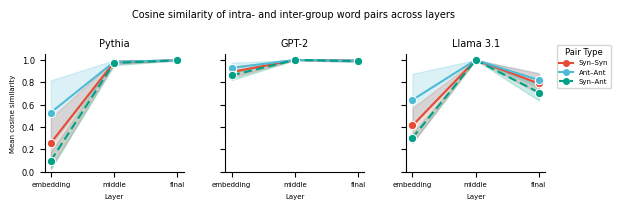

In [ ]:
plot_cosine_summary_intra_inter_jitter(df_all, savepath="./cosine_distances.png")